In [29]:
# 1. Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [30]:
# 2. Load the dataset
df = pd.read_csv('data/processed/Defensive_Stats_Matrix_2003_2025.csv')

In [31]:
# 3. Select relevant columns for clustering
features = [
    'age', 'd_rtg', 'pace', 'opp_e_fg_percent', 'opp_tov_percent', 'opp_ft_fga',
    'drb_per_game', 'stl_per_game', 'blk_per_game', 'pf_per_game',
    'opp_fg_per_game', 'opp_fg_percent', 'opp_x3p_per_game', 'opp_x3p_percent',
    'opp_x2p_per_game', 'opp_x2p_percent', 'opp_ft_per_game', 'opp_fta_per_game',
    'opp_orb_per_game', 'opp_ast_per_game', 'opp_tov_per_game', 'opp_pts_per_game'
]

X = df[features]


In [32]:
# 4. Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

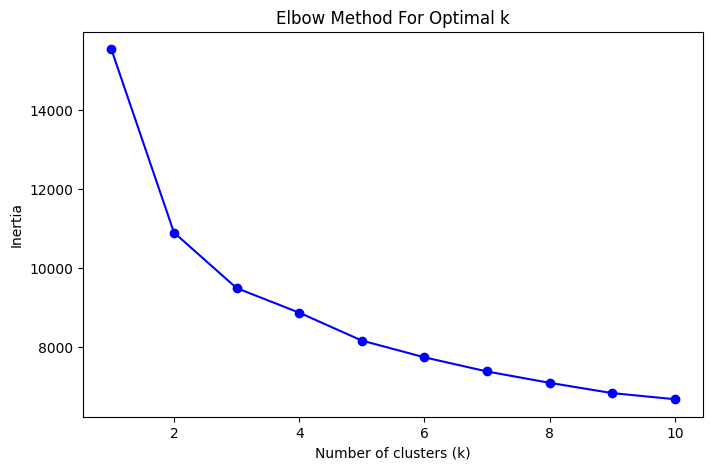

In [33]:
# 5. Find optimal number of clusters using the elbow method
inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()


In [34]:
# 6. Fit KMeans with optimal k (let's assume k=4 from elbow method, adjust after seeing elbow plot)
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X_scaled)
df['cluster'] = kmeans.labels_


Explained variance by component: [0.40958457 0.19254239 0.1134522 ]
Total explained variance: 0.72


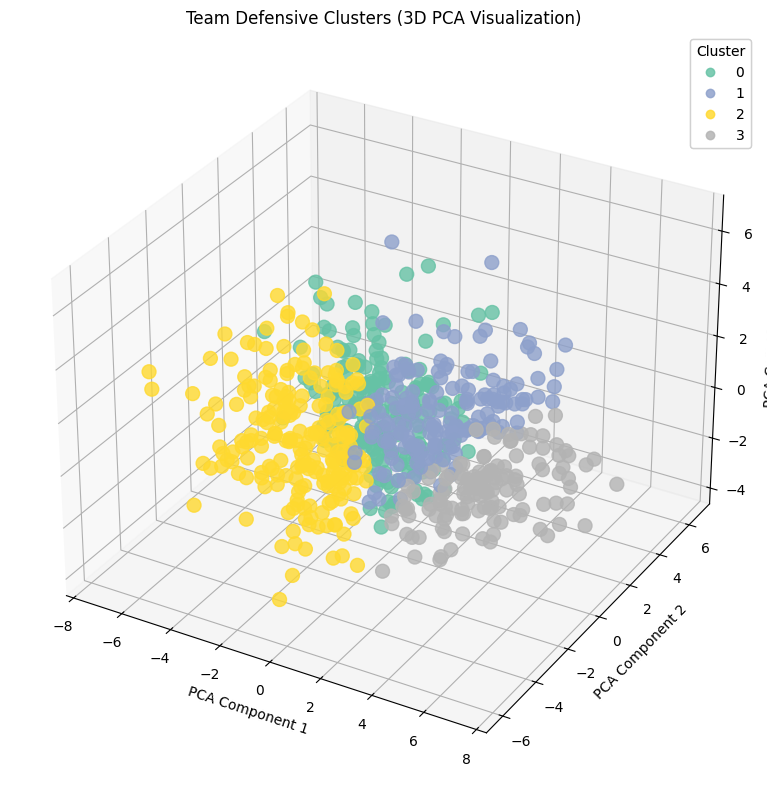

In [35]:
# 7. Visualize clusters using 3D PCA
pca = PCA(n_components=3)  # Change to 3 components for 3D visualization
X_pca = pca.fit_transform(X_scaled)

# Create a 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Create scatter plot with all three components
scatter = ax.scatter(
    X_pca[:, 0], 
    X_pca[:, 1], 
    X_pca[:, 2],
    c=df['cluster'],  # Color by cluster
    cmap='Set2',      # Use same color scheme
    s=100,            # Point size
    alpha=0.8         # Transparency for better visibility
)

# Add labels and title
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')
plt.title('Team Defensive Clusters (3D PCA Visualization)')

# Add legend
legend = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend)

# Print explained variance for each component
explained_variance = pca.explained_variance_ratio_
print(f"Explained variance by component: {explained_variance}")
print(f"Total explained variance: {sum(explained_variance):.2f}")

plt.tight_layout()
plt.show()

In [36]:
# 8. Analyze cluster centers
cluster_centers = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=features)
cluster_centers['cluster'] = range(4)
cluster_centers

,age,d_rtg,pace,opp_e_fg_percent,opp_tov_percent,opp_ft_fga,drb_per_game,stl_per_game,blk_per_game,pf_per_game,...,opp_x3p_percent,opp_x2p_per_game,opp_x2p_percent,opp_ft_per_game,opp_fta_per_game,opp_orb_per_game,opp_ast_per_game,opp_tov_per_game,opp_pts_per_game,cluster
0,25.975758,108.369192,92.690404,0.502298,13.707576,0.242990,29.976768,7.550000,4.694444,22.054040,...,0.363712,30.863636,0.489939,19.681313,25.938889,11.424747,22.084343,14.707071,101.246465,0
1,26.104938,110.051235,98.443827,0.525741,13.249383,0.204383,33.535185,8.096296,4.940123,20.357407,...,0.358296,28.725926,0.520154,17.743827,23.009877,10.294444,24.221605,14.813580,109.075926,1
2,27.516055,103.735321,91.466514,0.481225,13.520183,0.213546,31.592202,7.512385,5.088532,20.290826,...,0.347028,29.605046,0.470225,17.324771,22.998624,11.041284,20.655505,14.290826,95.616055,2
3,26.294531,113.784375,98.554688,0.539008,11.832031,0.187883,33.842969,7.139062,4.675781,19.007031,...,0.362664,29.689844,0.536625,16.739062,21.557813,10.407813,25.490625,13.234375,112.864063,3


In [37]:
# 9. Optional: View examples of teams in each cluster
for c in sorted(df['cluster'].unique()):
    print(f"\nCluster {c} Teams:")
    display(df[df['cluster'] == c][['season', 'team', 'abbreviation']])


Cluster 0 Teams:


,season,team,abbreviation
2,2003,Chicago Bulls,CHI
3,2003,Cleveland Cavaliers,CLE
5,2003,Denver Nuggets,DEN
7,2003,Golden State Warriors,GSW
11,2003,Los Angeles Clippers,LAC
...,...,...,...
426,2016,Portland Trail Blazers,POR
455,2017,Philadelphia 76ers,PHI
456,2017,Phoenix Suns,PHO
457,2017,Portland Trail Blazers,POR



Cluster 1 Teams:


,season,team,abbreviation
159,2008,Denver Nuggets,DEN
283,2012,Denver Nuggets,DEN
311,2013,Charlotte Bobcats,CHA
318,2013,Houston Rockets,HOU
339,2014,Atlanta Hawks,ATL
...,...,...,...
696,2025,Oklahoma City Thunder,OKC
697,2025,Orlando Magic,ORL
698,2025,Philadelphia 76ers,PHI
700,2025,Portland Trail Blazers,POR



Cluster 2 Teams:


,season,team,abbreviation
0,2003,Atlanta Hawks,ATL
1,2003,Boston Celtics,BOS
4,2003,Dallas Mavericks,DAL
6,2003,Detroit Pistons,DET
8,2003,Houston Rockets,HOU
...,...,...,...
448,2017,Miami Heat,MIA
459,2017,San Antonio Spurs,SAS
461,2017,Utah Jazz,UTA
464,2018,Boston Celtics,BOS



Cluster 3 Teams:


,season,team,abbreviation
167,2008,Memphis Grizzlies,MEM
330,2013,Orlando Magic,ORL
333,2013,Portland Trail Blazers,POR
353,2014,Los Angeles Lakers,LAL
403,2016,Brooklyn Nets,BRK
...,...,...,...
699,2025,Phoenix Suns,PHO
701,2025,Sacramento Kings,SAC
702,2025,San Antonio Spurs,SAS
704,2025,Utah Jazz,UTA


/var/folders/k5/1511xdl10db532886zr1dzb40000gn/T/ipykernel_54968/919489601.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y='season', data=df, palette='Set2')


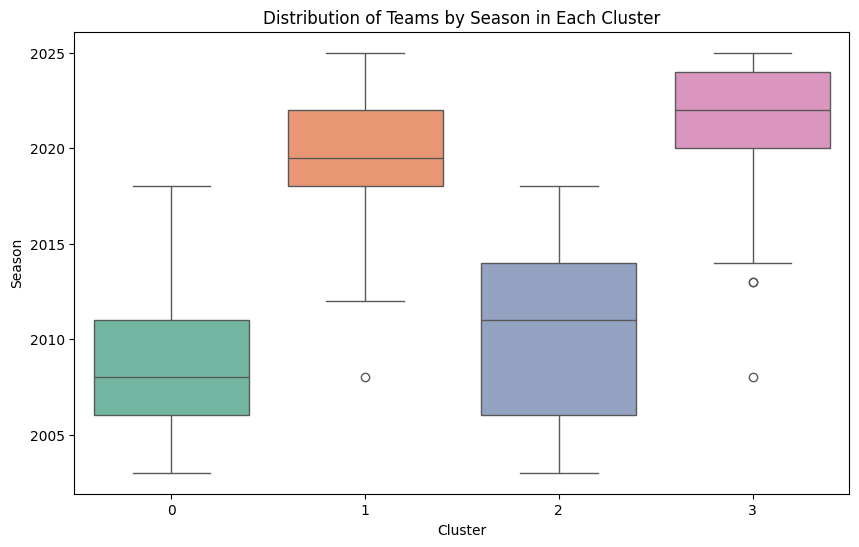

In [38]:
# 10. Boxplot: Distribution of teams by season for each cluster
plt.figure(figsize=(10, 6))
sns.boxplot(x='cluster', y='season', data=df, palette='Set2')
plt.title('Distribution of Teams by Season in Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Season')
plt.show()

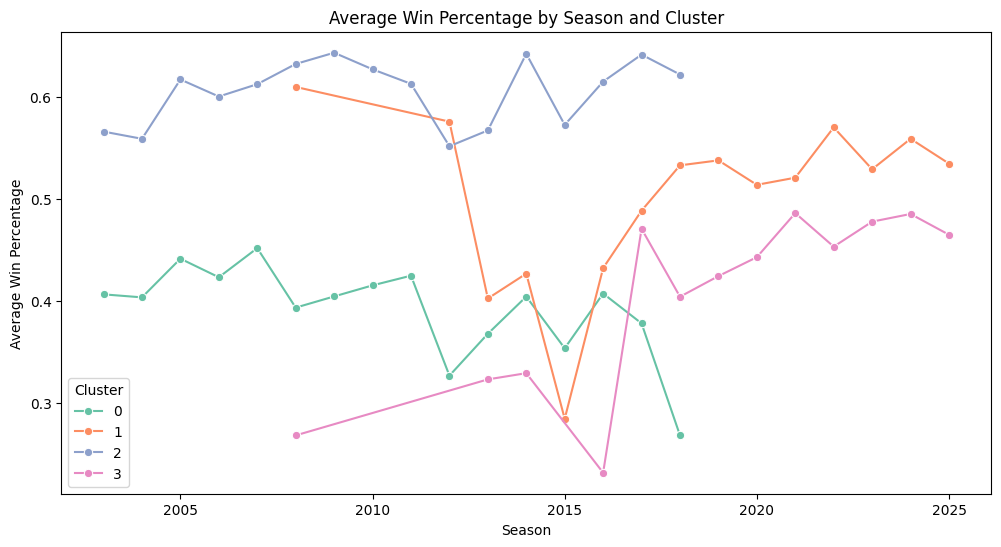

In [39]:
# 11. Visualization: Average win percentage by season and cluster
df['win_percentage'] = df['w'] / (df['w'] + df['l'])

avg_win_by_season_cluster = df.groupby(['season', 'cluster'])['win_percentage'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=avg_win_by_season_cluster, x='season', y='win_percentage', hue='cluster', palette='Set2', marker='o')
plt.title('Average Win Percentage by Season and Cluster')
plt.xlabel('Season')
plt.ylabel('Average Win Percentage')
plt.legend(title='Cluster')
plt.show()

In [40]:
df.to_csv('data/processed/Defensive_Stats_with_Clusters_2003_2025.csv', index=False)

print("✅ Clustered defensive stats saved to 'data/processed/Defensive_Stats_with_Clusters_2003_2025.csv'")

✅ Clustered defensive stats saved to 'data/processed/Defensive_Stats_with_Clusters_2003_2025.csv'
